# 第1章 程序设计基础

🔖为保持章节序号与课本一致，此处为章标题占位符，具体内容请参阅对应章的 ipynb 文件。

# 第2章 Python 语言基础

🔖为保持章节序号与课本一致，此处为章标题占位符，具体内容请参阅对应章的 ipynb 文件。

# 第3章 基本控制结构

🔖为保持章节序号与课本一致，此处为章标题占位符，具体内容请参阅对应章的 ipynb 文件。

# 第4章 复合数据类型

🏍️想象一下，如果你穿越回上世纪 90 年代上大学，想要实现本章讲述的 Python 中内置列表、元组、集合和字典。恭喜你，你不得不学习一门新的课程——《数据结构》，必须亲手在内存中管理地址：用动态数组或指针链表构建列表与元组，用哈希表算法设计字典，用栈与队列的逻辑处理顺序操作。

还好 Python 为你做好了一切。不过面向性能敏感、大数据分析与科学计算场景，第三方库例如 NumPy、Pandas 等是更好的选择。 

**Python 数据处理生态的技术选型：内置类型、NumPy 与 Pandas**

❗以下内容使用 Qwen3.5:9B 生成

在 Python 数据科学与分析的工程实践中，数据容器与计算库的选择直接决定了算法执行效率与开发维护成本。针对通用逻辑处理、大规模数值运算及结构化数据管理这三类典型需求，Python 原生数据类型（Built-in Types）、NumPy 数组以及 Pandas 数据框分别占据了不同的生态位。以下从底层实现机制、性能特征及适用边界三个维度进行严谨阐述。

一、Python 内置类型：灵活性与通用逻辑的基石

Python 的内置数据结构主要包括列表（`list`）、字典（`dict`）、元组（`tuple`）和集合（`set`）。它们基于 Python 对象模型实现，具有动态类型与丰富的 API。
*   适用场景：适用于业务逻辑控制、数据配置管理、中小规模的数据序列化/反序列化以及非密集型的通用数据处理。例如，在脚本编写中快速原型验证，或处理异构数据的键值映射时，内置类型的灵活性无可替代。
*   性能局限：由于解释器开销（Interpreter Overhead）及对象指针间接寻址机制，当数据规模超出十万级或涉及循环遍历、密集运算时，其时间复杂度往往呈现 $O(n)$ 甚至更差的线性瓶颈，且内存占用较高（每个元素包含类型信息）。此外，无法直接利用 SIMD 指令集进行硬件加速。

二、NumPy：大规模数值计算与向量化运算的底层引擎

`numpy.ndarray` 是 Python 科学计算的基石，其核心优势在于对内存管理的优化及 C 语言级别的实现。
*   适用场景：优先应用于大规模矩阵运算、物理模拟、图像处理以及深度学习预处理等需要高吞吐量的数值密集型任务。
*   性能机制：
    1.  连续内存布局（Contiguous Memory Layout）：NumPy 数组在内存中通常按行主序排列，消除了 Python 对象列表的指针跳转开销，显著提升了缓存命中率。
    2.  向量化运算（Vectorization）：通过广播机制（Broadcasting），支持对成百上千元素进行并行操作而无需编写显式 `for` 循环，从而绕过 Python 解释器的逐行执行瓶颈。
    3.  底层扩展：可调用 BLAS、LAPACK 等优化库，实现接近原生 C/Fortran 的浮点运算速度。

三、Pandas：带索引的表格数据管理与 ETL 工作流
Pandas 构建于 NumPy 之上（核心数据结构 Series/DataFrame 底层存储为 `ndarray`），侧重于数据的结构化管理与工程化流转。
*   适用场景：适用于结构化表格数据处理、时间序列分析、缺失值插补、复杂分组聚合及数据清洗流程自动化。
*   功能特性：
    1.  轴对齐（Alignment）：Pandas 独有的索引机制允许基于标签而非位置进行操作，支持多索引（MultiIndex）的层级检索，极大提升了表格数据的可读性与查询效率。
    2.  元数据支持：原生处理数据类型推断、缺失值标记（NaN/NA）、日期时间解析等复杂语义，这是纯 NumPy 难以直接处理的。
    3.  I/O 集成：提供对 CSV, Excel, SQL 等多种格式的高效读写接口，是连接数据库与计算模型的理想中间层。

在实际开发中，这三者并非互斥关系，而是构成了分层协作的生态：Python 内置类型负责控制流与逻辑编排，NumPy 提供底层的计算内核，Pandas 则作为面向用户的表格操作接口。

建议遵循“通用逻辑用原生，数值计算用 NumPy，结构化分析用 Pandas”的原则。当业务场景跨越这些边界时（如既需要表格处理又需要底层矩阵运算），应优先利用 Pandas 对 NumPy 的封装能力，仅在 Pandas 无法胜任的高性能计算节点上回退至纯 NumPy 或 C/C++ 扩展，以在开发效率与系统性能之间取得最优平衡。

## 认识复合类型

### 由简单类型到复合类型

数据结构决定操作程序结构，回顾第3章的例子，简单类型：

In [1]:
for line in open('data/scores.csv', 'r', encoding='utf-8'):
    parts = line.strip().split(',')
    if len(parts) < 4 or '"ID"' == parts[0]:
        continue
    gs, yy, cx = float(parts[1]), float(parts[2]), float(parts[3])
    print((gs + yy + cx) / 3)

85.0
84.66666666666667
86.0
71.33333333333333


使用列表推导式计算平均成绩：

1. 把所有的成绩（含空白行）放到一个列表中，元素是所有科目成绩的字符串；
2. 对原列表逐元素去空白符，使用逗号进行切分，得到新列表，元素是列表，包含 3 科成绩的字符串，或者异常数据包含一个空字符串；
3. 过滤原列表，保留长度为 3 的元素，并将每个元素的子元素转换为浮点型，得到新列表，元素是列表，包含 3 科成绩的浮点数；
4. 对原列表逐元素计算平均值，`sum(x)` 得 x 中所有元素的和，`len(x)` 返回 x 中元素的个数，即 $\text{mean}(x)=\dfrac{\sum\limits_{i = 1}^{3}x_i}{3}$，得到新列表，元素是平均成绩。

In [2]:
data_list = open('data/scores.csv', 'r', encoding='utf-8').readlines()[1:] # 1
print(data_list)
data_list = [x.strip().split(',') for x in data_list] # 2
print(data_list)
data_list = [[float(y) for y in x[1:]] for x in data_list if len(x) == 4] # 3
print(data_list)
data_list = [sum(x)/len(x) for x in data_list] # 4
print(data_list)

['"1001",85,92,78\n', '"1002",76,88,90\n', '"1003",91,85,82\n', '"1004",70,65,79\n', '\n']
[['"1001"', '85', '92', '78'], ['"1002"', '76', '88', '90'], ['"1003"', '91', '85', '82'], ['"1004"', '70', '65', '79'], ['']]
[[85.0, 92.0, 78.0], [76.0, 88.0, 90.0], [91.0, 85.0, 82.0], [70.0, 65.0, 79.0]]
[85.0, 84.66666666666667, 86.0, 71.33333333333333]


### 复合类型概述

NetworkX 是很好的图工具包，下面是使用该工具包加载空手道俱乐部数据集，并可视化展示的示例：

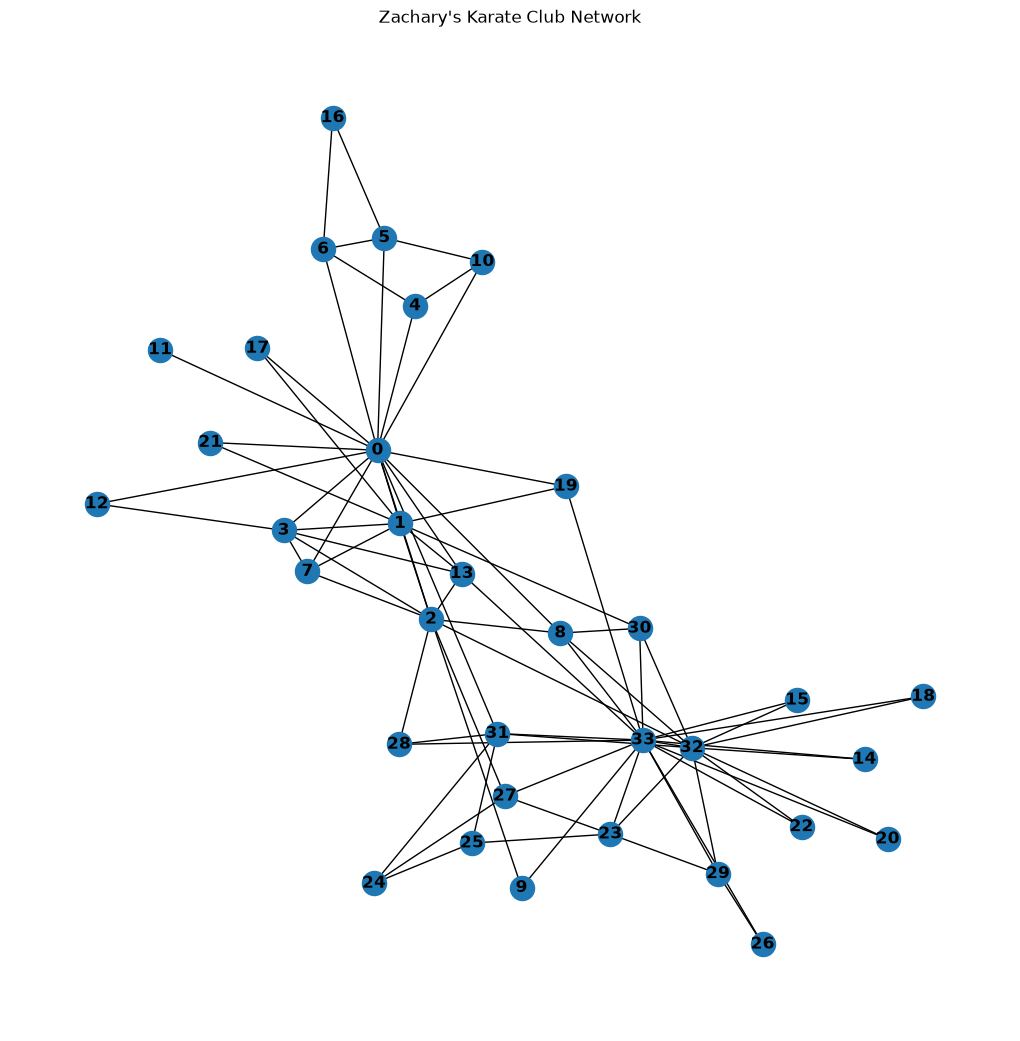

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 使用 NetworkX 内置的空手道俱乐部数据集
G = nx.karate_club_graph()

# 绘图
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=True, font_weight='bold')
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

### Python 复合数据类型

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 序列类型 --- list, tuple, range

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 集合类型 --- set, frozenset

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 序列类型 --- 映射类型 --- dict

### ✍️伴读札记

#### 📚数据结构很重要，但不是现在！

得益于 Python 高度抽象且语义直观的内置复合数据类型（如列表、字典、集合等），非计算机背景的理工科学生能够跳过底层内存管理、指针操作及特定数据结构算法的实现细节，直接利用现成的高层容器模型来映射现实世界的科学问题。这种设计极大地降低了认知门槛，使学习者能将精力集中在领域逻辑（Domain Logic）与**数学建模**本身，而非软件工程的底层实现。

Python 的 `list` 在处理小规模数据或逻辑控制流时表现优异，但在大规模科学计算（如处理百万级浮点数组）时，其性能远不如专门的数值库。Python 生态通过引入 NumPy、PyTorch 等第三方库，在继承“免手写数据结构”优势的同时，引入了基于 C/Fortran 优化的多维数组（ndarray）和张量。对于非 CS 学生而言，“远离构建复杂数据结构”不仅指内置类型，更延伸到了整个 Python 科学计算栈。他们不需要写一个 `Matrix` 类，直接调用 NumPy 的矩阵运算即可。

## 序列类

### 序列类概述

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 序列类型 --- list, tuple, range

### 字符串

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 文本序列类型 --- str

### 列表

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 序列类型 --- list, tuple, range

### 元组

🔖请参阅\[Python 文档——Python 标准库\] » 内置类型 » 序列类型 --- list, tuple, range

### ✍️伴读札记


#### 🦥Python 迭代器与生成器

一、迭代器（Iterator）

核心概念：实现了迭代器协议的对象，即同时定义了 `__iter__()` 和 `__next__()` 方法。

- `__iter__()` 返回迭代器自身
- `__next__()` 返回下一个值，耗尽时抛出 `StopIteration`

```python
class CountDown:
    def __init__(self, start):
        self.current = start

    def __iter__(self):
        return self

    def __next__(self):
        if self.current <= 0:
            raise StopIteration
        self.current -= 1
        return self.current + 1
```

可迭代对象（Iterable）：实现了 `__iter__()` 并返回迭代器的对象（如 list、dict、str），本身不一定是迭代器。`iter(x)` 可将可迭代对象转为迭代器。

---

二、生成器（Generator）

核心概念：用 `yield` 关键字定义的特殊迭代器，由 Python 自动实现迭代器协议，无需手写 `__iter__` / `__next__`。

```python
def count_down(start):
    while start > 0:
        yield start
        start -= 1
```

调用生成器函数不会执行函数体，而是返回一个生成器对象；每次 `next()` 驱动执行到下一个 `yield` 并暂停，保留局部状态。

生成器表达式：`(x*x for x in range(10))`，语法类似列表推导但惰性求值。

---

三、关键区别与联系

| 维度 | 迭代器 | 生成器 |
|------|--------|--------|
| 实现方式 | 类 + `__iter__`/`__next__` | 函数 + `yield` |
| 状态管理 | 手动维护实例属性 | 自动保存帧与局部变量 |
| 代码量 | 较多 | 简洁 |
| 本质 | 协议 | 迭代器的语法糖 |

共同特点：都是惰性求值，一次只产生一个值，内存占用与数据量无关，适合处理大文件或无限序列。只能遍历一次，耗尽后需重新创建。


#### 👎基于列表进行数值运算，不是个好主义

🏍️Python 支持多种程序编写风格，对于`加载数据集并进行计算`这类常规操作：C/C++/Java 背景的开发者习惯使用 for 循环逐条处理；追求 Python 风格的人偏爱列表推导式；具备 Hadoop MapReduce 经验的工程师倾向函数式编程与生成器；而BI 背景的分析师则更青睐 Pandas。

参照 3.4.1 求平均成绩的例子，设计实验展示这几种方法的特点，实验过程如下：
1. 构造数据集，取决于机器配置和实验者所能忍耐的时间，建议至少在百万级，贴近实战效果；
2. 分别使用 for 循环结构、列表推导式、生成器、Pandas，加载数据集求有效记录数，平均成绩的最大值及其对应的三科成绩，使用使用魔术命令 `%%time` 记录执行时间

##### ➕构造数据集

参照 data/scores.csv 格式构造数据，`TOTAL_RECORDS` 为有效记录数，ID 为 0 开始的字符串，成绩随机生成，最后添加一条错误记录：

In [4]:
import csv
import random

import pandas as pd

TOTAL_RECORDS = 1*10**6

with open('data/large.csv', 'w', encoding='utf-8') as f:
    f.write('"ID","gs","yy","cx"\n')
    lines = [f'"{i}",{",".join(map(str, random.sample(range(60, 100), 3)))}\n' 
             for i in range(TOTAL_RECORDS)]
    f.writelines(lines)   
    f.write('"BADONE"\n')


##### 🔄for 循环结构
直观感觉使用 for 循环结构直接求记录数和平均成绩的最大值，循环体内只累加记录数 count，和保存平均成绩的最大值，应该最快：

In [5]:
%%timeit -r 5 -n 1
count = 0
avg_max = 0
score_max = ()

for line in open('data/large.csv', 'r', encoding='utf-8'):
    row = line.strip().split(',')
    try:
        score = (float(row[1]), float(row[2]), float(row[3]))
        avg = sum(score)/3
        if avg_max < avg:
            avg_max = avg
            score_max = (row[0].replace('"', ''), score, avg)
        count = count + 1
    except ValueError:
        pass
    except IndexError:
        pass
    
print(count, avg_max, score_max)

1000000 98.0 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 98.0 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 98.0 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 98.0 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 98.0 ('5759', (97.0, 99.0, 98.0), 98.0)
662 ms ± 17.4 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


使用列表存储平均成绩，然后求列表的记录数和最大值，循环内多了向列表追加记录的动作，少了缓存平均成绩最大值和累计记录数：

In [6]:
%%timeit -r 5 -n 1
res = []

for line in open('data/large.csv', 'r', encoding='utf-8'):
    row = line.strip().split(',')
    try:
        score = (float(row[1]), float(row[2]), float(row[3]))
        avg = sum(score)/3
        res.append((row[0].replace('"', ''), score, avg))
    except ValueError:
        pass
    except IndexError:
        pass

print(len(res), max(res, key=lambda x: x[2]))

1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
915 ms ± 13.5 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


与预期差不多，向列表中插入对象，确实要慢一些。

##### ➡️列表推导式

一次性将整个文件内容读取到内存中，生成一个包含所有行字符串的列表，使用列表推导式进行格式转换得到新的列表，再次使用列表推导式剔除不合约的数据得到合约的列表：

In [7]:
%%timeit -r 5 -n 1
def single_record(row):
    scores = row.strip().split(',') 
    try:
        score = (float(scores[1]), float(scores[2]), float(scores[3])) 
        return (scores[0].replace('"', ''), score, sum(score)/3)
    except ValueError:
        return None
    except IndexError:
        return None

data_list = open('data/large.csv', 'r', encoding='utf-8').readlines()
data_list = [single_record(x) for x in data_list]
data_list = [x for x in data_list if x]
print(len(data_list), max(data_list, key=lambda x: x[2]))

1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1.06 s ± 19.4 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


In [8]:
%%timeit -r 5 -n 1
def single_record(row):
    scores = row.strip().split(',') 
    try:
        score = (float(scores[1]), float(scores[2]), float(scores[3])) 
        return (scores[0].replace('"', ''), score, sum(score)/3)
    except ValueError:
        return None
    except IndexError:
        return None

data_list = open('data/large.csv', 'r', encoding='utf-8').readlines()
data_list = (single_record(x) for x in data_list)
data_list = [x for x in data_list if x]
print(len(data_list), max(data_list, key=lambda x: x[2]))

1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1.03 s ± 21.5 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


让我们逐一分析性能上的“槽点”：

1. `readlines()` 会一次性把整个文件加载到内存中，变成 Python 对象列表。如果文件大，这会直接导致进程 OOM (Memory Limit Exceeded) 或物理内存交换 (Swap)，严重拖慢速度；
2. 使用列表推导式过滤不合约的数据，多了一次生成中间列表的动作。


##### ⚡生成器

`生成器`是一个用于创建迭代器的简单而强大的工具。它们的写法类似于标准的函数，但当它们要返回数据时会使用 yield 语句。 每次在生成器上调用 next() 时，它会从上次离开的位置恢复执行（它会记住上次执行语句时的所有数据值）。

```
def my_reader(file_name):

    for line in open(file_name, 'r', encoding='utf-8'):
        try:
            row = line.strip().split(',')
            score = (float(row[1]), float(row[2]), float(row[3]))
            yield (row[0].replace('"', ''), score, sum(score)/3)
        except ValueError:
            pass
        except IndexError:
            pass
```

生成器 yield 合约的数据，因此由该对生成器构造的迭代器可以直接通过 list() 得到最终的列表：

In [9]:
%%timeit -r 5 -n 1
def my_reader(file_name):

    for line in open(file_name, 'r', encoding='utf-8'):
        try:
            row = line.strip().split(',')
            score = (float(row[1]), float(row[2]), float(row[3]))
            yield (row[0].replace('"', ''), score, sum(score)/3)
        except ValueError:
            pass
        except IndexError:
            pass

data_list = list(my_reader('data/large.csv'))
print(len(data_list), max(data_list, key=lambda x: x[2]))

1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
1000000 ('5759', (97.0, 99.0, 98.0), 98.0)
930 ms ± 17.7 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


##### 🐼Pandas

处理表格类型数据当属 Pandas，加载 CSV 文件时识别表头，进行类型转换，识别异常数据一气呵成；计算 gs、yy、cx 三列的平均值保存到 avg 列；找出 avg 列最大值的第1条记录：

df = pd.read_csv('data/large.csv', header=0, on_bad_lines='skip', dtype={'ID':str}).dropna()
df['avg'] = (df['gs'] + df['yy'] + df['cx']) / 3
print(len(df), df.loc[df['avg'].idxmax()])

In [10]:
%%timeit -r 5 -n 1
df = pd.read_csv('data/large.csv', header=0, on_bad_lines='skip', dtype={'ID':str}).dropna()
df['avg'] = (df['gs'] + df['yy'] + df['cx']) / 3
print(len(df), df.loc[df['avg'].idxmax()])

1000000 ID     5759
gs     97.0
yy     99.0
cx     98.0
avg    98.0
Name: 5759, dtype: object
1000000 ID     5759
gs     97.0
yy     99.0
cx     98.0
avg    98.0
Name: 5759, dtype: object
1000000 ID     5759
gs     97.0
yy     99.0
cx     98.0
avg    98.0
Name: 5759, dtype: object
1000000 ID     5759
gs     97.0
yy     99.0
cx     98.0
avg    98.0
Name: 5759, dtype: object
1000000 ID     5759
gs     97.0
yy     99.0
cx     98.0
avg    98.0
Name: 5759, dtype: object
558 ms ± 77.6 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


Pandas 执行速度遥遥领先。

其实 Pandas 最大的优势是它支持丰富的数学运算能力，包括基础算术、统计函数、广播机制、向量化操作和条件计算等。

 基本算术运算（加减乘除），例如刚刚演示过的求平均值：

In [11]:
df = pd.read_csv('data/large.csv', header=0, on_bad_lines='skip', dtype={'ID':str}).dropna()
df['avg'] = (df['gs'] + df['yy'] + df['cx']) / 3
df.loc[df['avg'] == 98]

,ID,gs,yy,cx,avg
5759,5759,97.0,99.0,98.0,98.0
16506,16506,99.0,97.0,98.0,98.0
22170,22170,99.0,98.0,97.0,98.0
24038,24038,98.0,97.0,99.0,98.0
25856,25856,97.0,99.0,98.0,98.0
...,...,...,...,...,...
915693,915693,97.0,98.0,99.0,98.0
915793,915793,98.0,97.0,99.0,98.0
928485,928485,99.0,97.0,98.0,98.0
948543,948543,97.0,99.0,98.0,98.0


统计函数，算算平均分数的中位数：

In [12]:
df['avg'].median()

np.float64(79.66666666666667)

条件计算（布尔运算），找出平均成绩低于 62 分的同学：

In [13]:
df.loc[df['avg'] < 62]

,ID,gs,yy,cx,avg
1677,1677,60.0,63.0,62.0,61.666667
1903,1903,62.0,60.0,63.0,61.666667
2311,2311,61.0,60.0,64.0,61.666667
2944,2944,64.0,60.0,61.0,61.666667
5062,5062,62.0,61.0,60.0,61.000000
...,...,...,...,...,...
985614,985614,61.0,60.0,64.0,61.666667
987753,987753,60.0,62.0,63.0,61.666667
991299,991299,64.0,60.0,61.0,61.666667
992310,992310,63.0,62.0,60.0,61.666667


最后删除生成的文件：

In [14]:
from pathlib import Path
Path('data/large.csv').unlink()

##### 🤝总结

经过对不同编程风格（传统循环、列表推导式、函数式生成器、Pandas）在“加载数据集与计算”场景下的性能与功能对比，结论是明确的：在处理结构化数据与批量计算时，Pandas 库凭借其底层优化的向量化操作，在运行效率（尤其是大数据量下）和代码可读性上均优于原生 Python 语法。

面对多种编程风格，我们不应将其视为“二选一”的对立关系，而应建立分层级的认知体系：

第一阶段：夯实基础（理解底层）

不要一开始就完全依赖 Pandas。初学者必须掌握 `for` 循环、列表推导式以及生成器。这不仅是为了写出 Pythonic 的代码，更是为了理解数据在内存中是如何流转的。理解了原生操作的开销，你未来在使用 Pandas 等高级库时，才能明白“向量化”带来的性能红利究竟从何而来，避免陷入“只知其然不知其所以然”的黑盒陷阱。

第二阶段：拥抱工具（追求效率）

当你的代码逻辑进入数据处理领域，请毫不犹豫地转向 Pandas、NumPy 等科学计算库。在工程中，“合适”比“纯粹”更重要。但在数据分析场景下，强行使用原生循环不仅开发效率低（容易写错），运行性能也往往无法接受。Pandas 封装了底层优化，让你将精力集中在业务逻辑而非内存管理上。

第三阶段：混合应用（工程思维）

成熟的 Python 开发者通常具备“混合风格”的能力：用 Pandas 处理核心数据清洗与分析，在特定性能敏感点或自定义逻辑中回归原生写法以解决边缘问题。

## 集合

### 集合运算

🔖请参阅[Python 文档——Python 标准库] » 内置类型 » 集合类型 --- set, frozenset

### 集合操作

🔖请参阅[Python 文档——Python 标准库] » 内置类型 » 集合类型 --- set, frozenset

### 集合应用案例

🔖请参阅[Python 文档——Python 标准库] » 内置类型 » 集合类型 --- set, frozenset

### ✍️伴读札记

#### 🧮判断一个元素是否已在集合（`set`）中

Python 的 `set` 是基于哈希表实现的无序数据结构。每个元素通过内置函数 `hash()` 计算出一个整数哈希值，该值用于确定其在内部存储中的位置。由于哈希冲突可能将多个元素映射到同一位置，因此使用了开放寻址法（open addressing）+ 二次探测等机制来处理碰撞问题。

判断成员存在性： 平均时间复杂度为 O(1)，最坏情况为 O(n)。使用 `in` 操作在列表中查找元素需要遍历，平均时间复杂度为 O(n)。因此，对于频繁进行“是否存在”查询的场景，集合是更优选择。

极端情况下（如所有元素哈希相同），集合查找可能退化为 O(n)，可通过自定义类控制 `__hash__` 和 `__eq__` 方法优化。

下面是最差的例子， `__hash__` 方法返回固定值， `__eq__` 方法返回 True：

In [15]:
class BadClass:
    def __init__(self, value):
        self.value = value
    
    def __hash__(self):
        return 123456  

    def __eq__(self, b):
        return True

obj1 = BadClass("A")
obj2 = BadClass("B")
s = {obj1}
s.add(obj2) 
print(obj1, obj2)
print(s)

<__main__.BadClass object at 0x7dc7cdb4af90> <__main__.BadClass object at 0x7dc7cdbe0f50>
{<__main__.BadClass object at 0x7dc7cdb4af90>}


In [16]:
s = {1, 'a', 3.5}
type(s)

set

## 字典

### 字典概述

🔖请参阅[Python 文档——Python 标准库] » 内置类型 » 序列类型 --- 映射类型 --- dict

### 字典操作

🔖请参阅[Python 文档——Python 标准库] » 内置类型 » 序列类型 --- 映射类型 --- dict

### 字典应用案例

🔖请参阅[Python 文档——Python 标准库] » 内置类型 » 序列类型 --- 映射类型 --- dict

### ✍️伴读札记
#### 📄JSON

**JSON**（JavaScript Object Notation）是一种轻量级的数据交换格式，广泛用于 Web 开发、API 交互、配置文件等领域。它易于人类阅读，也便于机器解析。

特点：
- 基于文本的键值对结构
- 支持对象、数组、字符串、数字、布尔值和 null
- 兼容 JavaScript，但独立于任何语言

```json
{
  "name": "张三",
  "age": 25,
  "isStudent": false,
  "hobbies": ["阅读", "编程"],
  "address": {
    "city": "北京"
  }
}
```

Python 标准库 `json` 提供了将 JSON 序列化为字符串（编码）和从字符串反解析为 Python 对象（解码）的功能。

1. 序列化：将 Python 对象转换为 JSON 字符串

In [17]:
import json
data = {
    "name": "张三",
    "age": 25,
    "isStudent": False,
    "hobbies": ["阅读", "编程"],
    "address": {"city": "北京"}
}

json_str = json.dumps(data, ensure_ascii=False)
print(json_str)

{"name": "张三", "age": 25, "isStudent": false, "hobbies": ["阅读", "编程"], "address": {"city": "北京"}}


2. 反序列化：将 JSON 字符串转换为 Python 对象

In [18]:
from pprint import pprint
obj = json.loads(json_str)
pprint(obj)

{'address': {'city': '北京'},
 'age': 25,
 'hobbies': ['阅读', '编程'],
 'isStudent': False,
 'name': '张三'}


## 习题
### 编程题
1\. 2021年中国小麦产量共13694（单位：万 t），其中新疆 639、陕西 424、河南 3802、安徽 1699、江苏 1342、河北 1469、山东 2636，以上各省份中产量排名前三的省份分别是哪些？前三的省份小麦产量占全国总产量的比例为多少？

In [19]:
# 数据：2021年各省小麦产量（单位：万t）
data = {
    "新疆": 639,
    "陕西": 424,
    "河南": 3802,
    "安徽": 1699,
    "江苏": 1342,
    "河北": 1469,
    "山东": 2636
}

# 全国总产量
total = 13694

# 按产量降序排序，取前三个
sorted_items = sorted(data.items(), key=lambda x: x[1], reverse=True)
top3 = sorted_items[:3]

# 计算前三省份产量之和
top3_sum = sum(item[1] for item in top3)

# 计算占比（百分比）
ratio = top3_sum / total * 100

# 输出结果
print("产量排名前三的省份：")
for i, (province, output) in enumerate(top3, 1):
    print(f"  {i}. {province}：{output} 万t")

print(f"\n前三省份总产量：{top3_sum} 万t")
print(f"占全国总产量比例：{ratio:.2f}%")

产量排名前三的省份：
  1. 河南：3802 万t
  2. 山东：2636 万t
  3. 安徽：1699 万t

前三省份总产量：8137 万t
占全国总产量比例：59.42%


2\. 已知有字符串`"only today is a gift"`，使用切片方式获取其中前三个单词，然后在不使用切片及`split()`方法的情况下，通过循环判定截取并输出前三个单词。

In [20]:
s = "only today is a gift"

# ---------- 方式一：使用 split + 切片 ----------
words_split = s.split()          # 分割成单词列表
first_three_slice = words_split[:3]   # 列表切片取前三个
print("使用 split 和切片获取前三个单词:", first_three_slice)

# ---------- 方式二：不用 split 和切片，纯循环截取 ----------
result = []          # 存放截取到的单词
word = ""            # 临时拼凑当前单词
count = 0            # 已截取单词个数

for ch in s:
    if ch == ' ':               # 遇到空格，说明一个单词结束
        if word:                # 防止连续空格（本题没有）
            result.append(word)
            word = ""
            count += 1
            if count == 3:      # 截到三个单词就提前退出
                break
    else:
        word += ch              # 非空格字符，拼接到当前单词

# 如果循环正常结束且未截够3个，但末尾还有单词（本题不会发生，因为4个单词）
# 但为了通用，处理最后一个单词
else:
    if word and count < 3:
        result.append(word)

# 输出循环截取的结果
print("不使用 split 和切片，循环截取前三个单词:", result)

使用 split 和切片获取前三个单词: ['only', 'today', 'is']
不使用 split 和切片，循环截取前三个单词: ['only', 'today', 'is']


3\. 使用元组 `tup = (0,1,2,3,4,5)` 中的元素，生成包含不同数字的四位数，共有多少种结果？请将结果连续输出于一行中。

In [21]:
from itertools import permutations

tup = (0, 1, 2, 3, 4, 5)
results = []

# 生成所有4位排列，过滤首位非0
for perm in permutations(tup, 4):
    if perm[0] != 0:
        # 将元组转为整数（如 (1,2,3,4) -> 1234）
        num = int(''.join(map(str, perm)))
        results.append(num)

# 按数值升序排列（可选）
results.sort()

# 输出总数
print(f"共有 {len(results)} 个结果：")
# 连续输出所有结果，空格分隔
print(' '.join(map(str, results)))

共有 300 个结果：
1023 1024 1025 1032 1034 1035 1042 1043 1045 1052 1053 1054 1203 1204 1205 1230 1234 1235 1240 1243 1245 1250 1253 1254 1302 1304 1305 1320 1324 1325 1340 1342 1345 1350 1352 1354 1402 1403 1405 1420 1423 1425 1430 1432 1435 1450 1452 1453 1502 1503 1504 1520 1523 1524 1530 1532 1534 1540 1542 1543 2013 2014 2015 2031 2034 2035 2041 2043 2045 2051 2053 2054 2103 2104 2105 2130 2134 2135 2140 2143 2145 2150 2153 2154 2301 2304 2305 2310 2314 2315 2340 2341 2345 2350 2351 2354 2401 2403 2405 2410 2413 2415 2430 2431 2435 2450 2451 2453 2501 2503 2504 2510 2513 2514 2530 2531 2534 2540 2541 2543 3012 3014 3015 3021 3024 3025 3041 3042 3045 3051 3052 3054 3102 3104 3105 3120 3124 3125 3140 3142 3145 3150 3152 3154 3201 3204 3205 3210 3214 3215 3240 3241 3245 3250 3251 3254 3401 3402 3405 3410 3412 3415 3420 3421 3425 3450 3451 3452 3501 3502 3504 3510 3512 3514 3520 3521 3524 3540 3541 3542 4012 4013 4015 4021 4023 4025 4031 4032 4035 4051 4052 4053 4102 4103 4105 4120 4123 412

4\. 小麦是我国北方地区的主要农作物，小麦品种的外在分类标准包含颜色、质地、季节，用元组表示为 `t1 = ('红色','白色')`、`t2 = ('硬质','软质')`、`t3 = ('春','冬')`，通过组合三个元组中的元素，输出小麦的所有分类。

In [22]:
t1 = ('红色', '白色')
t2 = ('硬质', '软质')
t3 = ('春', '冬')

for color in t1:
    for texture in t2:
        for season in t3:
            print(f'{color}{texture}{season}', end='  ')

红色硬质春  红色硬质冬  红色软质春  红色软质冬  白色硬质春  白色硬质冬  白色软质春  白色软质冬  

In [23]:
from itertools import product

t1 = ('红色', '白色')
t2 = ('硬质', '软质')
t3 = ('春', '冬')

for combo in product(t1, t2, t3):
    print(''.join(combo), end='  ')

红色硬质春  红色硬质冬  红色软质春  红色软质冬  白色硬质春  白色硬质冬  白色软质春  白色软质冬  

In [24]:
t1 = ('红色', '白色')
t2 = ('硬质', '软质')
t3 = ('春', '冬')

all_types = [c + t + s for c in t1 for t in t2 for s in t3]
print('  '.join(all_types))

红色硬质春  红色硬质冬  红色软质春  红色软质冬  白色硬质春  白色硬质冬  白色软质春  白色软质冬


5\. 现有5位学生信息如表4‑8所示，通过集合的方式分别找出喜欢篮球、rap的三好学生，仅喜欢打篮球的学生，所有没有获得荣誉的同学（所有的同学都有爱好）。

表4‑8 学生信息

|姓名|爱好|荣誉|
| ---- | ---- | ---- |
|小张|篮球、rap|三好学生|
|小杨|rap|奖学金|
|小陈|篮球|奖学金|
|小郭|rap| |
|小南|篮球|三好学生、奖学金|

In [25]:
# 学生信息：爱好用集合表示，荣誉用集合表示
students = {
    '小张': {'爱好': {'篮球', 'rap'}, '荣誉': {'三好学生'}},
    '小杨': {'爱好': {'rap'}, '荣誉': {'奖学金'}},
    '小陈': {'爱好': {'篮球'}, '荣誉': {'奖学金'}},
    '小郭': {'爱好': {'rap'}, '荣誉': set()},          # 空集表示无荣誉
    '小南': {'爱好': {'篮球'}, '荣誉': {'三好学生', '奖学金'}}
}

# 构建各兴趣和荣誉的集合（学生姓名）
all_students = set(students.keys())
basketball_lovers = {name for name, info in students.items() if '篮球' in info['爱好']}
rap_lovers = {name for name, info in students.items() if 'rap' in info['爱好']}
sanhao_students = {name for name, info in students.items() if '三好学生' in info['荣誉']}

# 1. 喜欢篮球的三好学生（交集）
basketball_sanhao = basketball_lovers & sanhao_students

# 2. 喜欢 rap 的三好学生（交集）
rap_sanhao = rap_lovers & sanhao_students

# 3. 仅喜欢打篮球的学生（爱好集合恰为 {'篮球'}）
only_basketball = {name for name, info in students.items() if info['爱好'] == {'篮球'}}

# 4. 没有获得荣誉的同学（荣誉集合为空）
no_honor = {name for name, info in students.items() if not info['荣誉']}

# 输出结果
print("喜欢篮球的三好学生：", basketball_sanhao)
print("喜欢rap的三好学生：", rap_sanhao)
print("仅喜欢打篮球的学生：", only_basketball)
print("没有获得荣誉的同学：", no_honor)

喜欢篮球的三好学生： {'小张', '小南'}
喜欢rap的三好学生： {'小张'}
仅喜欢打篮球的学生： {'小南', '小陈'}
没有获得荣誉的同学： {'小郭'}


6\. 向列表中输入多个数字，输出其中重复出现过的数字。

In [26]:
import random

# 随机生成 10 个 1~20 之间的整数（可自行调整数量和范围）
num_count = 10
min_val = 1
max_val = 20

# 生成随机数字列表
nums = [random.randint(min_val, max_val) for _ in range(num_count)]

# 统计每个数字出现的次数
counter = {}
for num in nums:
    counter[num] = counter.get(num, 0) + 1

# 找出重复出现的数字（去重）
duplicates = [num for num, count in counter.items() if count > 1]

# 输出原始列表和重复数字
print("随机生成的数字列表：", nums)
if duplicates:
    print("重复出现过的数字有：", duplicates)
else:
    print("没有重复出现的数字。")

随机生成的数字列表： [17, 20, 17, 9, 16, 1, 6, 16, 12, 9]
重复出现过的数字有： [17, 9, 16]


7\. 输入一个字典，然后完成对字典键‑值的转置。提示：可以分为使用生成式与不使用生成式两种方式。

In [27]:
from collections import defaultdict

# 自行构建一个字典（包含重复值，便于演示）
original = {'a': 1, 'b': 2, 'c': 1, 'd': 3}

print("原字典：", original)

# ---------- 方式一：不使用生成式（显式循环） ----------
new_dict1 = {}
for k, v in original.items():
    if v in new_dict1:
        # 已存在，转为列表存储多个键
        if isinstance(new_dict1[v], list):
            new_dict1[v].append(k)
        else:
            new_dict1[v] = [new_dict1[v], k]
    else:
        new_dict1[v] = k

# ---------- 方式二：使用生成式（列表推导 + defaultdict） ----------
# 生成 (新键, 旧键) 对的列表（生成式）
pairs = [(v, k) for k, v in original.items()]
# 合并重复值（循环不可避免，但之前用了生成式）
new_dict2 = defaultdict(list)
for nk, ok in pairs:
    new_dict2[nk].append(ok)
# 若列表长度为1，则转为单值（字典推导，也是生成式风格）
new_dict2 = {k: (v[0] if len(v) == 1 else v) for k, v in new_dict2.items()}

print("转置结果（不含生成式）：", new_dict1)
print("转置结果（含生成式）：", new_dict2)

原字典： {'a': 1, 'b': 2, 'c': 1, 'd': 3}
转置结果（不含生成式）： {1: ['a', 'c'], 2: 'b', 3: 'd'}
转置结果（含生成式）： {1: ['a', 'c'], 2: 'b', 3: 'd'}


8\. 我国小麦按质量指标分为五等，其中容重是定等指标，可记录为 `grade = {'一等':790,'二等':770,'三等':750,'四等':730,'五等':710}`，单位（g/L）。输入当前小麦的容重值，判定其应属于几等小麦。

In [28]:
# 小麦等级标准（g/L）
grade = {'一等': 790, '二等': 770, '三等': 750, '四等': 730, '五等': 710}

# 自行给定的容重值（可修改此数值）
capacity = 755

# 判定等级
if capacity >= grade['一等']:
    result = '一等'
elif capacity >= grade['二等']:
    result = '二等'
elif capacity >= grade['三等']:
    result = '三等'
elif capacity >= grade['四等']:
    result = '四等'
elif capacity >= grade['五等']:
    result = '五等'
else:
    result = '等外（不合格）'

print(f"容重 {capacity} g/L 属于：{result}")

容重 755 g/L 属于：三等
